In [3]:
import pandas as pd

data = pd.read_csv("tickets.csv")

print(data.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [4]:
print(data.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')


In [5]:
import pandas as pd

data = pd.read_csv("tickets.csv")

data = data[["Ticket Description", "Ticket Type"]]

print(data.head())

                                  Ticket Description      Ticket Type
0  I'm having an issue with the {product_purchase...  Technical issue
1  I'm having an issue with the {product_purchase...  Technical issue
2  I'm facing a problem with my {product_purchase...  Technical issue
3  I'm having an issue with the {product_purchase...  Billing inquiry
4  I'm having an issue with the {product_purchase...  Billing inquiry


In [6]:
print(data.isnull().sum())

Ticket Description    0
Ticket Type           0
dtype: int64


In [7]:
data = data.dropna()

In [8]:
import nltk
import string

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\Teja
[nltk_data]     Reddy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [9]:
data["Ticket Description"] = data["Ticket Description"].str.lower()

data["Ticket Description"] = data["Ticket Description"].str.replace(r'[^\w\s]', '', regex=True)

print(data["Ticket Description"].head())

0    im having an issue with the product_purchased ...
1    im having an issue with the product_purchased ...
2    im facing a problem with my product_purchased ...
3    im having an issue with the product_purchased ...
4    im having an issue with the product_purchased ...
Name: Ticket Description, dtype: str


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(data["Ticket Description"])

In [11]:
y = data["Ticket Type"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [14]:
predictions = model.predict(X_test)

print(predictions[:10])

['Refund request' 'Technical issue' 'Refund request'
 'Cancellation request' 'Technical issue' 'Refund request'
 'Refund request' 'Billing inquiry' 'Product inquiry' 'Product inquiry']


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.1894923258559622


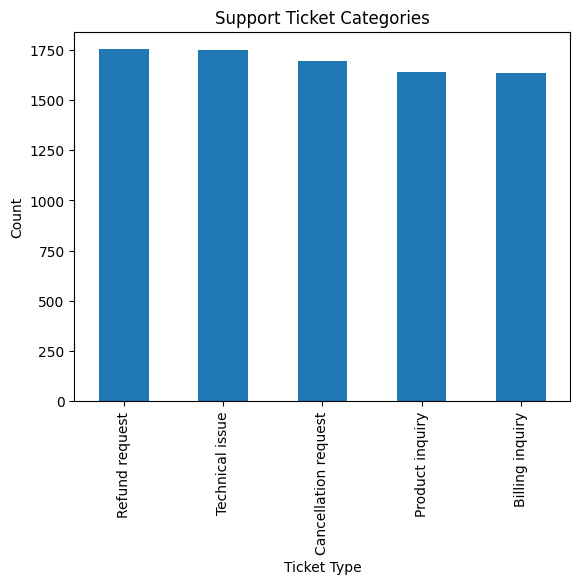

In [16]:
import matplotlib.pyplot as plt

data["Ticket Type"].value_counts().plot(kind="bar")

plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.title("Support Ticket Categories")

plt.show()

# Conclusion

This project classifies customer support tickets using Natural Language Processing and Machine Learning.

## Technologies Used
- Python
- NLTK
- TF-IDF
- Scikit-learn
- Naive Bayes

## Key Learnings
- Text preprocessing
- Ticket classification
- NLP feature extraction
- Machine Learning model training

In [1]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

NameError: name 'y_test' is not defined

In [2]:
import pandas as pd

data = pd.read_csv("tickets.csv")

data = data[["Ticket Description", "Ticket Type"]]

data = data.dropna()

In [3]:
data["Ticket Description"] = data["Ticket Description"].str.lower()

data["Ticket Description"] = data["Ticket Description"].str.replace(
    r'[^\w\s]',
    '',
    regex=True
)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(data["Ticket Description"])

In [5]:
y = data["Ticket Type"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [8]:
predictions = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.1894923258559622


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.04      0.06       357
Cancellation request       0.17      0.16      0.17       327
     Product inquiry       0.16      0.11      0.13       316
      Refund request       0.20      0.32      0.25       345
     Technical issue       0.21      0.31      0.25       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[ 14  59  53 125 106]
 [ 11  52  55 108 101]
 [ 17  59  36 103 101]
 [ 25  59  44 112 105]
 [ 21  73  43 105 107]]


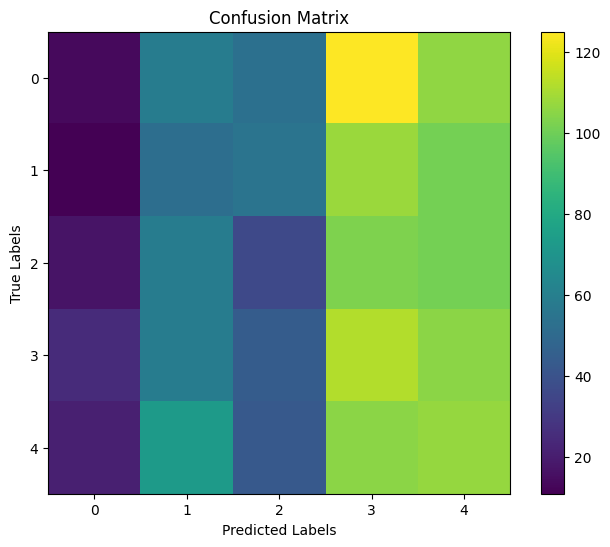

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.colorbar()

plt.show()

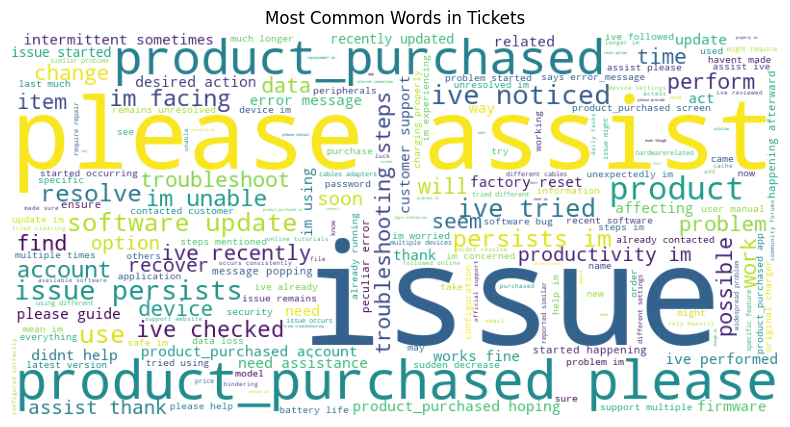

In [13]:
from wordcloud import WordCloud

text = " ".join(data["Ticket Description"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Words in Tickets")

plt.show()

In [14]:
sample_ticket = [
    "unable to login to my account"
]

sample_vector = vectorizer.transform(sample_ticket)

prediction = model.predict(sample_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Cancellation request


# Business Insights

- NLP can automate customer support systems.
- Ticket classification reduces manual work.
- Automated support improves customer response time.
- Machine Learning enhances customer service efficiency.

# Final Conclusion

This project demonstrates how Natural Language Processing and Machine Learning can classify customer support tickets automatically.

The model preprocesses ticket descriptions, extracts features using TF-IDF, and predicts ticket categories using the Naive Bayes algorithm.